# Limb vs Neuron OpenSpliceAI 分数比较

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_theme(style='whitegrid')

In [3]:
limb_vcf = Path('/home1/xyf/data/openspliceai_tissue_data/variant/limb_400_all.vcf')
neuron_vcf = Path('/home1/xyf/data/openspliceai_tissue_data/variant/neuron_400_all.vcf')
print(f'Limb VCF exists: {limb_vcf.exists()}')
print(f'Neuron VCF exists: {neuron_vcf.exists()}')

Limb VCF exists: True
Neuron VCF exists: True


In [4]:
def load_openspliceai_vcf(path: Path) -> pd.DataFrame:
    records = []
    header = []
    with path.open() as handle:
        for line in handle:
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                header = line.strip().lstrip('#').split('	')
                continue
            if not line.strip():
                continue
            parts = line.rstrip().split('	')
            if header and len(parts) != len(header):
                continue
            chrom, pos, vid, ref, alt, qual, flt, info = parts[:8]
            base_row = {key: value for key, value in zip(header[: len(parts)], parts)} if header else {}
            info_dict = {}
            for field in info.split(';'):
                if '=' in field:
                    key, value = field.split('=', 1)
                    info_dict[key] = value
            annot = info_dict.get('OpenSpliceAI')
            if not annot or annot == '.':
                continue
            for entry in annot.split(','):
                bits = entry.split('|')
                if len(bits) < 10:
                    continue
                allele, gene = bits[0], bits[1]
                try:
                    ds_ag, ds_al, ds_dg, ds_dl = map(float, bits[2:6])
                    dp_ag, dp_al, dp_dg, dp_dl = map(float, bits[6:10])
                except ValueError:
                    continue
                record = base_row.copy() if base_row else {
                    'CHROM': chrom,
                    'POS': pos,
                    'ID': vid,
                    'REF': ref,
                    'ALT': alt,
                    'QUAL': qual,
                    'FILTER': flt,
                    'INFO': info,
                }
                record.setdefault('info_dict', info_dict)
                for key, value in info_dict.items():
                    if key == 'OpenSpliceAI':
                        continue
                    record[key] = value
                record.update({
                    'chrom': record.get('CHROM', chrom),
                    'pos': int(record.get('POS', pos)),
                    'ref': record.get('REF', ref),
                    'alt': record.get('ALT', alt),
                    'variant_id': record.get('ID', vid),
                    'allele': allele,
                    'gene': gene,
                    'ds_ag': ds_ag,
                    'ds_al': ds_al,
                    'ds_dg': ds_dg,
                    'ds_dl': ds_dl,
                    'dp_ag': dp_ag,
                    'dp_al': dp_al,
                    'dp_dg': dp_dg,
                    'dp_dl': dp_dl,
                    'variant_key': f"{chrom}:{pos}:{ref}>{alt}|{gene}"
                })
                records.append(record)
    df = pd.DataFrame.from_records(records)
    if not df.empty:
        ds_cols = ['ds_ag', 'ds_al', 'ds_dg', 'ds_dl']
        df['max_ds'] = df[ds_cols].max(axis=1)
    return df

In [5]:
limb_df = load_openspliceai_vcf(limb_vcf)
limb_df['dataset'] = 'limb'
neuron_df = load_openspliceai_vcf(neuron_vcf)
neuron_df['dataset'] = 'neuron'
combined = pd.concat([limb_df, neuron_df], ignore_index=True)
print(f'Limb entries: {len(limb_df)}')
print(f'Neuron entries: {len(neuron_df)}')

Limb entries: 5046
Neuron entries: 5046


In [6]:
select_col = ['ID','GENE','CONSEQUENCE','PHENOTYPES','ds_ag','ds_al','ds_dg','ds_dl','max_ds']
selected_df = combined[['dataset'] + select_col].copy()
selected_df.head()

,dataset,ID,GENE,CONSEQUENCE,PHENOTYPES,ds_ag,ds_al,ds_dg,ds_dl,max_ds
0,limb,1,USP14,stop_gained_Likely_LOF,Abnormality_of_the_breastAbnormality_of_the_ey...,0.0,0.00,0.0,0.02,0.02
1,limb,2,CCDC127,stop_gained_Likely_LOF,Abnormality_of_the_musculoskeletal_system,0.0,0.00,0.0,0.04,0.04
2,limb,3,THOC1,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.00,0.0,0.00,0.00
3,limb,4,SIRT3,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.00,0.0,0.00,0.00
4,limb,5,FAM234A,frameshift_variant_Likely_LOF,Abnormality_of_limbsAbnormality_of_the_musculo...,0.0,0.11,0.0,0.00,0.11


In [7]:
limb_sub = limb_df[select_col].drop_duplicates('ID').rename(columns={
    'ds_ag':'ds_ag_limb',
    'ds_al':'ds_al_limb',
    'ds_dg':'ds_dg_limb',
    'ds_dl':'ds_dl_limb',
    'max_ds':'max_ds_limb'
})

neuron_sub = neuron_df[select_col].drop_duplicates('ID').rename(columns={
    'ds_ag':'ds_ag_neuron',
    'ds_al':'ds_al_neuron',
    'ds_dg':'ds_dg_neuron',
    'ds_dl':'ds_dl_neuron',
    'max_ds':'max_ds_neuron'
})

merged_df = limb_sub.merge(neuron_sub, on='ID', how='outer', suffixes=('_limb','_neuron'), indicator=True)
merged_df.head()

,ID,GENE_limb,CONSEQUENCE_limb,PHENOTYPES_limb,ds_ag_limb,ds_al_limb,ds_dg_limb,ds_dl_limb,max_ds_limb,GENE_neuron,CONSEQUENCE_neuron,PHENOTYPES_neuron,ds_ag_neuron,ds_al_neuron,ds_dg_neuron,ds_dl_neuron,max_ds_neuron,_merge
0,1,USP14,stop_gained_Likely_LOF,Abnormality_of_the_breastAbnormality_of_the_ey...,0.0,0.0,0.00,0.02,0.02,USP14,stop_gained_Likely_LOF,Abnormality_of_the_breastAbnormality_of_the_ey...,0.0,0.0,0.00,0.02,0.02,both
1,10,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
2,100,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.78,0.01,0.78,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.79,0.01,0.79,both
3,1000,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
4,1001,ACSS1,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_the_...,0.0,0.0,0.00,0.00,0.00,ACSS1,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_the_...,0.0,0.0,0.00,0.00,0.00,both


In [8]:
set(merged_df['CONSEQUENCE_limb'])

{'frameshift_variant_Likely_LOF',
 'inframe_deletion_Protein_Changing',
 'inframe_insertion_Protein_Changing',
 'missense_variant_Protein_Changing',
 'splice_acceptor_variant_Likely_LOF',
 'splice_donor_region_variant_In_annotated_regulatory_region',
 'splice_donor_variant_Likely_LOF',
 'splice_polypyrimidine_tract_variant_In_annotated_regulatory_region',
 'splice_region_variant_In_annotated_regulatory_region',
 'start_lost_Likely_LOF',
 'stop_gained_Likely_LOF',
 'stop_lost_Protein_Changing'}

In [10]:
# 筛选PHENOTYPES_limb列中带有limb的行
filtered_df_limb = merged_df[merged_df['PHENOTYPES_limb'].str.contains('limb', case=False, na=False)]
print(f'筛选后的行数: {len(filtered_df_limb)}')
filtered_df_limb.head()


筛选后的行数: 1689


,ID,GENE_limb,CONSEQUENCE_limb,PHENOTYPES_limb,ds_ag_limb,ds_al_limb,ds_dg_limb,ds_dl_limb,max_ds_limb,GENE_neuron,CONSEQUENCE_neuron,PHENOTYPES_neuron,ds_ag_neuron,ds_al_neuron,ds_dg_neuron,ds_dl_neuron,max_ds_neuron,_merge
1,10,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
2,100,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.78,0.01,0.78,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.79,0.01,0.79,both
3,1000,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
8,1006,AMER2,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,AMER2,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
9,1007,ZNF521,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,ZNF521,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both


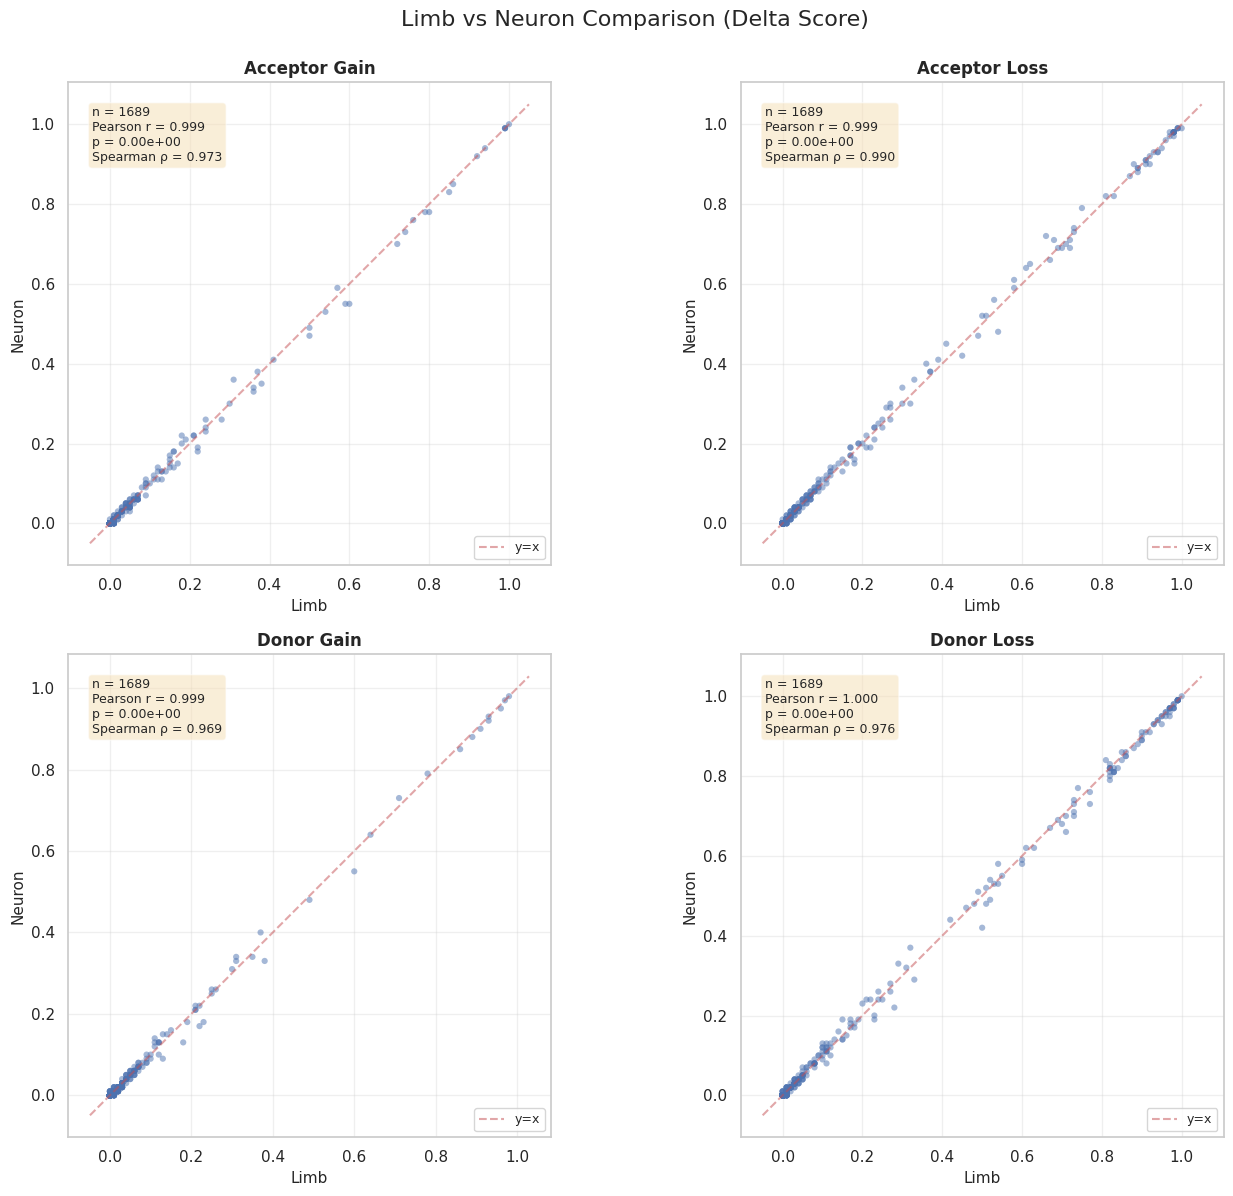

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 假设 merged_df_sp 已经在你的环境中定义
# 如果没有，请先加载数据

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Limb vs Neuron Comparison (Delta Score)', fontsize=16, y=0.995)

# 定义要比较的列对
comparisons = [
    ('ds_ag_limb', 'ds_ag_neuron', 'Acceptor Gain'),
    ('ds_al_limb', 'ds_al_neuron', 'Acceptor Loss'),
    ('ds_dg_limb', 'ds_dg_neuron', 'Donor Gain'),
    ('ds_dl_limb', 'ds_dl_neuron', 'Donor Loss')
]

# 扁平化axes数组以便迭代
axes_flat = axes.flatten()

# 为每个比较创建散点图
for idx, (limb_col, neuron_col, title) in enumerate(comparisons):
    ax = axes_flat[idx]
    
    # 提取数据并移除NaN值
    x = filtered_df_limb[limb_col].values
    y = filtered_df_limb[neuron_col].values
    
    # 创建mask来移除NaN值
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 绘制散点图
    ax.scatter(x_clean, y_clean, alpha=0.5, s=20, edgecolors='none')
    
    # 添加y=x参考线
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
            'r--', alpha=0.5, linewidth=1.5, label='y=x')
    
    # 计算相关系数
    if len(x_clean) > 0:
        corr, pval = stats.pearsonr(x_clean, y_clean)
        spearman_corr, spearman_pval = stats.spearmanr(x_clean, y_clean)
        
        # 添加统计信息
        stats_text = f'n = {len(x_clean)}\n'
        stats_text += f'Pearson r = {corr:.3f}\n'
        stats_text += f'p = {pval:.2e}\n'
        stats_text += f'Spearman ρ = {spearman_corr:.3f}'
        
        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)
    
    # 设置标签和标题
    ax.set_xlabel('Limb', fontsize=11)
    ax.set_ylabel('Neuron', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

In [12]:
# 筛选PHENOTYPES_limb列中带有limb的行
filtered_df_neuron = merged_df[merged_df['PHENOTYPES_limb'].str.contains('nervous', case=False, na=False)]
print(f'筛选后的行数: {len(filtered_df_neuron)}')
filtered_df_neuron.head()

筛选后的行数: 4152


,ID,GENE_limb,CONSEQUENCE_limb,PHENOTYPES_limb,ds_ag_limb,ds_al_limb,ds_dg_limb,ds_dl_limb,max_ds_limb,GENE_neuron,CONSEQUENCE_neuron,PHENOTYPES_neuron,ds_ag_neuron,ds_al_neuron,ds_dg_neuron,ds_dl_neuron,max_ds_neuron,_merge
0,1,USP14,stop_gained_Likely_LOF,Abnormality_of_the_breastAbnormality_of_the_ey...,0.0,0.0,0.00,0.02,0.02,USP14,stop_gained_Likely_LOF,Abnormality_of_the_breastAbnormality_of_the_ey...,0.0,0.0,0.00,0.02,0.02,both
1,10,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,DIP2C,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
2,100,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.78,0.01,0.78,MAEA,missense_variant_Protein_Changing,Abnormality_of_limbsAbnormality_of_the_breastA...,0.0,0.0,0.79,0.01,0.79,both
3,1000,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,THNSL1,stop_gained_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.0,0.0,0.00,0.00,0.00,both
4,1001,ACSS1,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_the_...,0.0,0.0,0.00,0.00,0.00,ACSS1,missense_variant_Protein_Changing,Abnormality_of_head_or_neckAbnormality_of_the_...,0.0,0.0,0.00,0.00,0.00,both


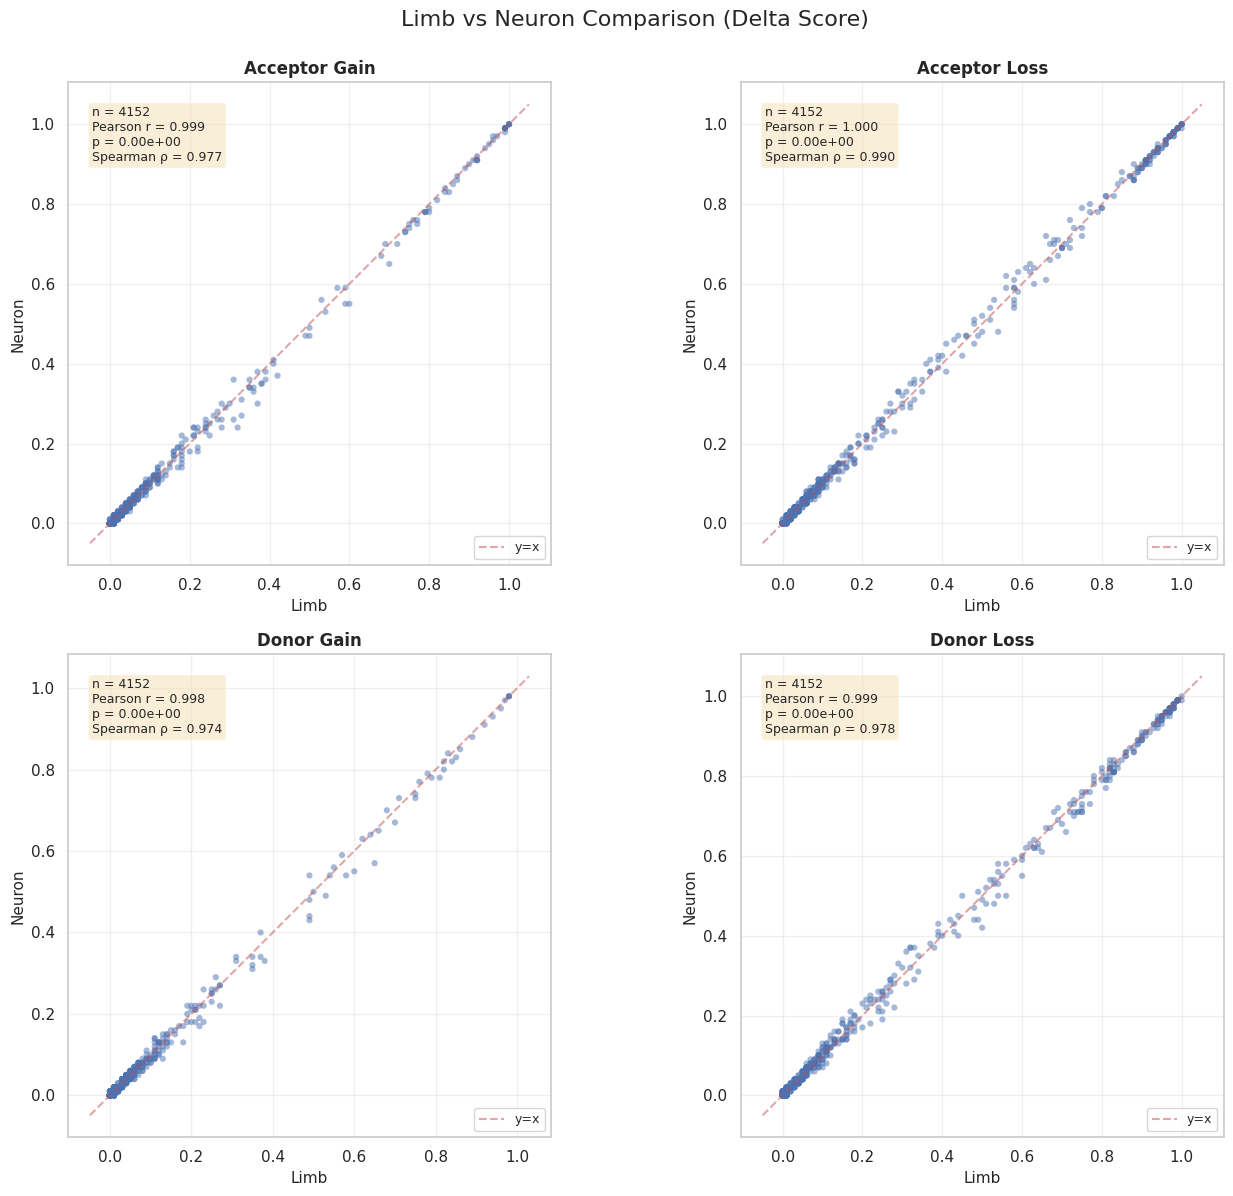

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 假设 merged_df_sp 已经在你的环境中定义
# 如果没有，请先加载数据

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Limb vs Neuron Comparison (Delta Score)', fontsize=16, y=0.995)

# 定义要比较的列对
comparisons = [
    ('ds_ag_limb', 'ds_ag_neuron', 'Acceptor Gain'),
    ('ds_al_limb', 'ds_al_neuron', 'Acceptor Loss'),
    ('ds_dg_limb', 'ds_dg_neuron', 'Donor Gain'),
    ('ds_dl_limb', 'ds_dl_neuron', 'Donor Loss')
]

# 扁平化axes数组以便迭代
axes_flat = axes.flatten()

# 为每个比较创建散点图
for idx, (limb_col, neuron_col, title) in enumerate(comparisons):
    ax = axes_flat[idx]
    
    # 提取数据并移除NaN值
    x = filtered_df_neuron[limb_col].values
    y = filtered_df_neuron[neuron_col].values
    
    # 创建mask来移除NaN值
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 绘制散点图
    ax.scatter(x_clean, y_clean, alpha=0.5, s=20, edgecolors='none')
    
    # 添加y=x参考线
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
            'r--', alpha=0.5, linewidth=1.5, label='y=x')
    
    # 计算相关系数
    if len(x_clean) > 0:
        corr, pval = stats.pearsonr(x_clean, y_clean)
        spearman_corr, spearman_pval = stats.spearmanr(x_clean, y_clean)
        
        # 添加统计信息
        stats_text = f'n = {len(x_clean)}\n'
        stats_text += f'Pearson r = {corr:.3f}\n'
        stats_text += f'p = {pval:.2e}\n'
        stats_text += f'Spearman ρ = {spearman_corr:.3f}'
        
        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)
    
    # 设置标签和标题
    ax.set_xlabel('Limb', fontsize=11)
    ax.set_ylabel('Neuron', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

In [45]:
merged_df_sp = merged_df[merged_df['CONSEQUENCE_limb'].isin(['splice_donor_variant_Likely_LOF','splice_acceptor_variant_Likely_LOF'])]


In [46]:
merged_df_sp

,ID,GENE_limb,CONSEQUENCE_limb,PHENOTYPES_limb,ds_ag_limb,ds_al_limb,ds_dg_limb,ds_dl_limb,max_ds_limb,GENE_neuron,CONSEQUENCE_neuron,PHENOTYPES_neuron,ds_ag_neuron,ds_al_neuron,ds_dg_neuron,ds_dl_neuron,max_ds_neuron,_merge
20,1017,TOP2B,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.00,0.00,0.00,0.23,0.23,TOP2B,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.00,0.00,0.00,0.20,0.20,both
21,1018,SCGN,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.00,0.00,0.98,0.98,SCGN,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.00,0.00,0.98,0.98,both
22,1019,SCGN,splice_donor_variant_Likely_LOF,Abnormality_of_the_digestive_systemAbnormality...,0.00,0.00,0.00,0.60,0.60,SCGN,splice_donor_variant_Likely_LOF,Abnormality_of_the_digestive_systemAbnormality...,0.00,0.00,0.00,0.60,0.60,both
27,1023,EXTL1,splice_donor_variant_Likely_LOF,Abnormality_of_the_nervous_system,0.00,0.00,0.00,0.81,0.81,EXTL1,splice_donor_variant_Likely_LOF,Abnormality_of_the_nervous_system,0.00,0.00,0.00,0.80,0.80,both
46,1040,GAD2,splice_acceptor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.25,0.00,0.00,0.25,GAD2,splice_acceptor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.22,0.00,0.00,0.22,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4643,925,ACIN1,splice_donor_variant_Likely_LOF,Abnormality_of_the_musculoskeletal_systemAbnor...,0.00,0.00,0.01,0.83,0.83,ACIN1,splice_donor_variant_Likely_LOF,Abnormality_of_the_musculoskeletal_systemAbnor...,0.00,0.00,0.01,0.84,0.84,both
4660,940,ELOA,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.00,0.00,0.00,0.70,0.70,ELOA,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_limb...,0.00,0.00,0.00,0.68,0.68,both
4694,973,CACNG3,splice_donor_variant_Likely_LOF,Abnormality_of_limbsAbnormality_of_the_musculo...,0.00,0.00,0.00,0.94,0.94,CACNG3,splice_donor_variant_Likely_LOF,Abnormality_of_limbsAbnormality_of_the_musculo...,0.00,0.00,0.00,0.94,0.94,both
4700,979,IZUMO3,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.00,0.02,0.63,0.63,IZUMO3,splice_donor_variant_Likely_LOF,Abnormality_of_head_or_neckAbnormality_of_the_...,0.00,0.00,0.02,0.64,0.64,both


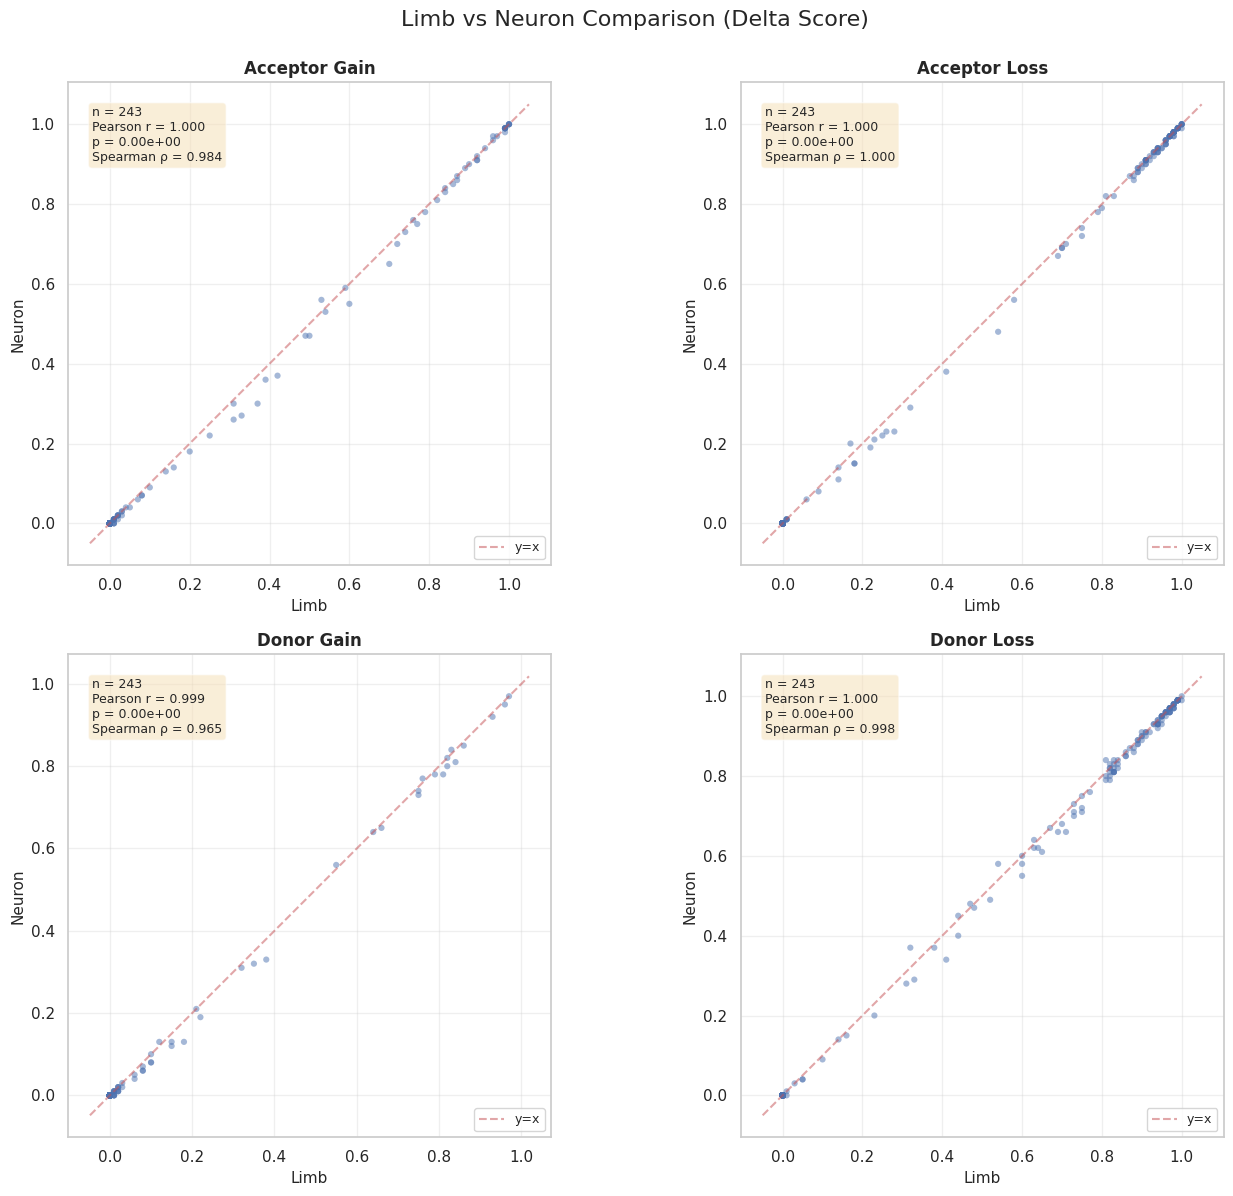

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 假设 merged_df_sp 已经在你的环境中定义
# 如果没有，请先加载数据

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Limb vs Neuron Comparison (Delta Score)', fontsize=16, y=0.995)

# 定义要比较的列对
comparisons = [
    ('ds_ag_limb', 'ds_ag_neuron', 'Acceptor Gain'),
    ('ds_al_limb', 'ds_al_neuron', 'Acceptor Loss'),
    ('ds_dg_limb', 'ds_dg_neuron', 'Donor Gain'),
    ('ds_dl_limb', 'ds_dl_neuron', 'Donor Loss')
]

# 扁平化axes数组以便迭代
axes_flat = axes.flatten()

# 为每个比较创建散点图
for idx, (limb_col, neuron_col, title) in enumerate(comparisons):
    ax = axes_flat[idx]
    
    # 提取数据并移除NaN值
    x = merged_df_sp[limb_col].values
    y = merged_df_sp[neuron_col].values
    
    # 创建mask来移除NaN值
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 绘制散点图
    ax.scatter(x_clean, y_clean, alpha=0.5, s=20, edgecolors='none')
    
    # 添加y=x参考线
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
            'r--', alpha=0.5, linewidth=1.5, label='y=x')
    
    # 计算相关系数
    if len(x_clean) > 0:
        corr, pval = stats.pearsonr(x_clean, y_clean)
        spearman_corr, spearman_pval = stats.spearmanr(x_clean, y_clean)
        
        # 添加统计信息
        stats_text = f'n = {len(x_clean)}\n'
        stats_text += f'Pearson r = {corr:.3f}\n'
        stats_text += f'p = {pval:.2e}\n'
        stats_text += f'Spearman ρ = {spearman_corr:.3f}'
        
        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)
    
    # 设置标签和标题
    ax.set_xlabel('Limb', fontsize=11)
    ax.set_ylabel('Neuron', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

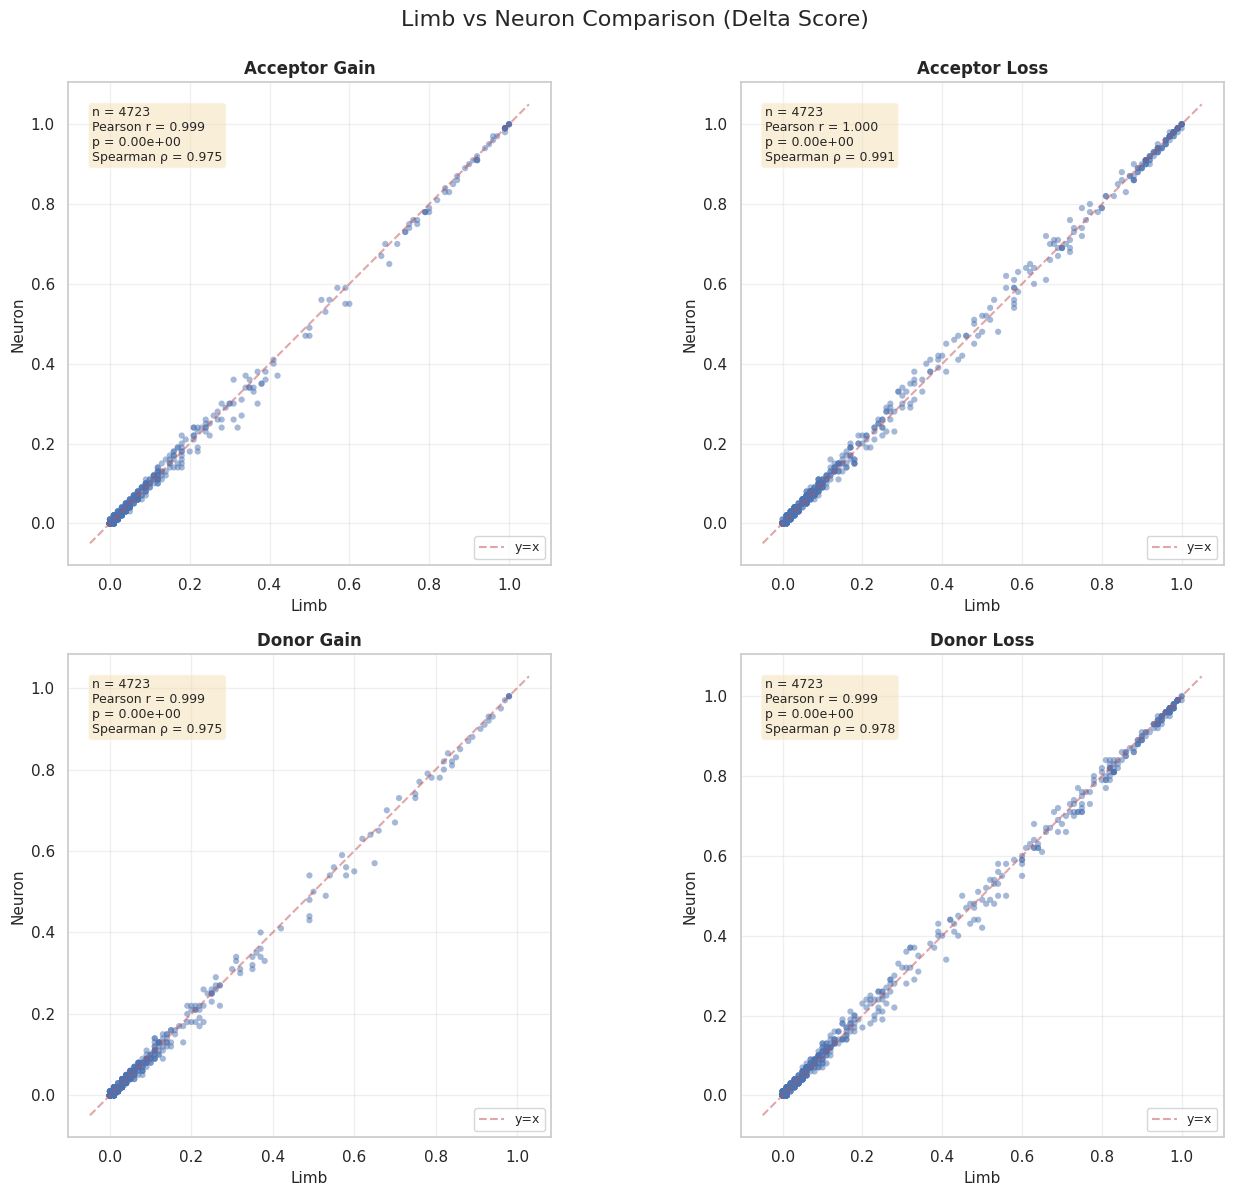

In [48]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 假设 merged_df_sp 已经在你的环境中定义
# 如果没有，请先加载数据

# 创建2x2的子图布局
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Limb vs Neuron Comparison (Delta Score)', fontsize=16, y=0.995)

# 定义要比较的列对
comparisons = [
    ('ds_ag_limb', 'ds_ag_neuron', 'Acceptor Gain'),
    ('ds_al_limb', 'ds_al_neuron', 'Acceptor Loss'),
    ('ds_dg_limb', 'ds_dg_neuron', 'Donor Gain'),
    ('ds_dl_limb', 'ds_dl_neuron', 'Donor Loss')
]

# 扁平化axes数组以便迭代
axes_flat = axes.flatten()

# 为每个比较创建散点图
for idx, (limb_col, neuron_col, title) in enumerate(comparisons):
    ax = axes_flat[idx]
    
    # 提取数据并移除NaN值
    x = merged_df[limb_col].values
    y = merged_df[neuron_col].values
    
    # 创建mask来移除NaN值
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # 绘制散点图
    ax.scatter(x_clean, y_clean, alpha=0.5, s=20, edgecolors='none')
    
    # 添加y=x参考线
    lim_min = min(ax.get_xlim()[0], ax.get_ylim()[0])
    lim_max = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 
            'r--', alpha=0.5, linewidth=1.5, label='y=x')
    
    # 计算相关系数
    if len(x_clean) > 0:
        corr, pval = stats.pearsonr(x_clean, y_clean)
        spearman_corr, spearman_pval = stats.spearmanr(x_clean, y_clean)
        
        # 添加统计信息
        stats_text = f'n = {len(x_clean)}\n'
        stats_text += f'Pearson r = {corr:.3f}\n'
        stats_text += f'p = {pval:.2e}\n'
        stats_text += f'Spearman ρ = {spearman_corr:.3f}'
        
        ax.text(0.05, 0.95, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                fontsize=9)
    
    # 设置标签和标题
    ax.set_xlabel('Limb', fontsize=11)
    ax.set_ylabel('Neuron', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

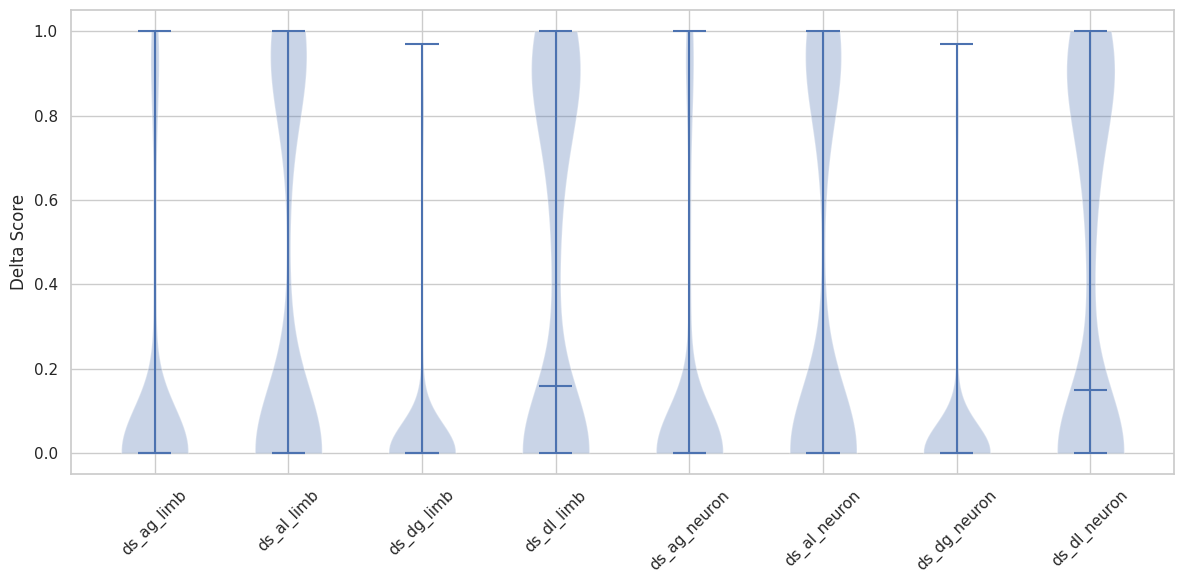

In [49]:
import matplotlib.pyplot as plt

# 小提琴图
columns = ['ds_ag_limb', 'ds_al_limb', 'ds_dg_limb', 'ds_dl_limb',
           'ds_ag_neuron', 'ds_al_neuron', 'ds_dg_neuron', 'ds_dl_neuron']

plt.figure(figsize=(12, 6))
plt.violinplot([merged_df_sp[col].dropna() for col in columns], 
               showmedians=True)
plt.xticks(range(1, 9), columns, rotation=45)
plt.ylabel('Delta Score')
plt.tight_layout()
plt.show()

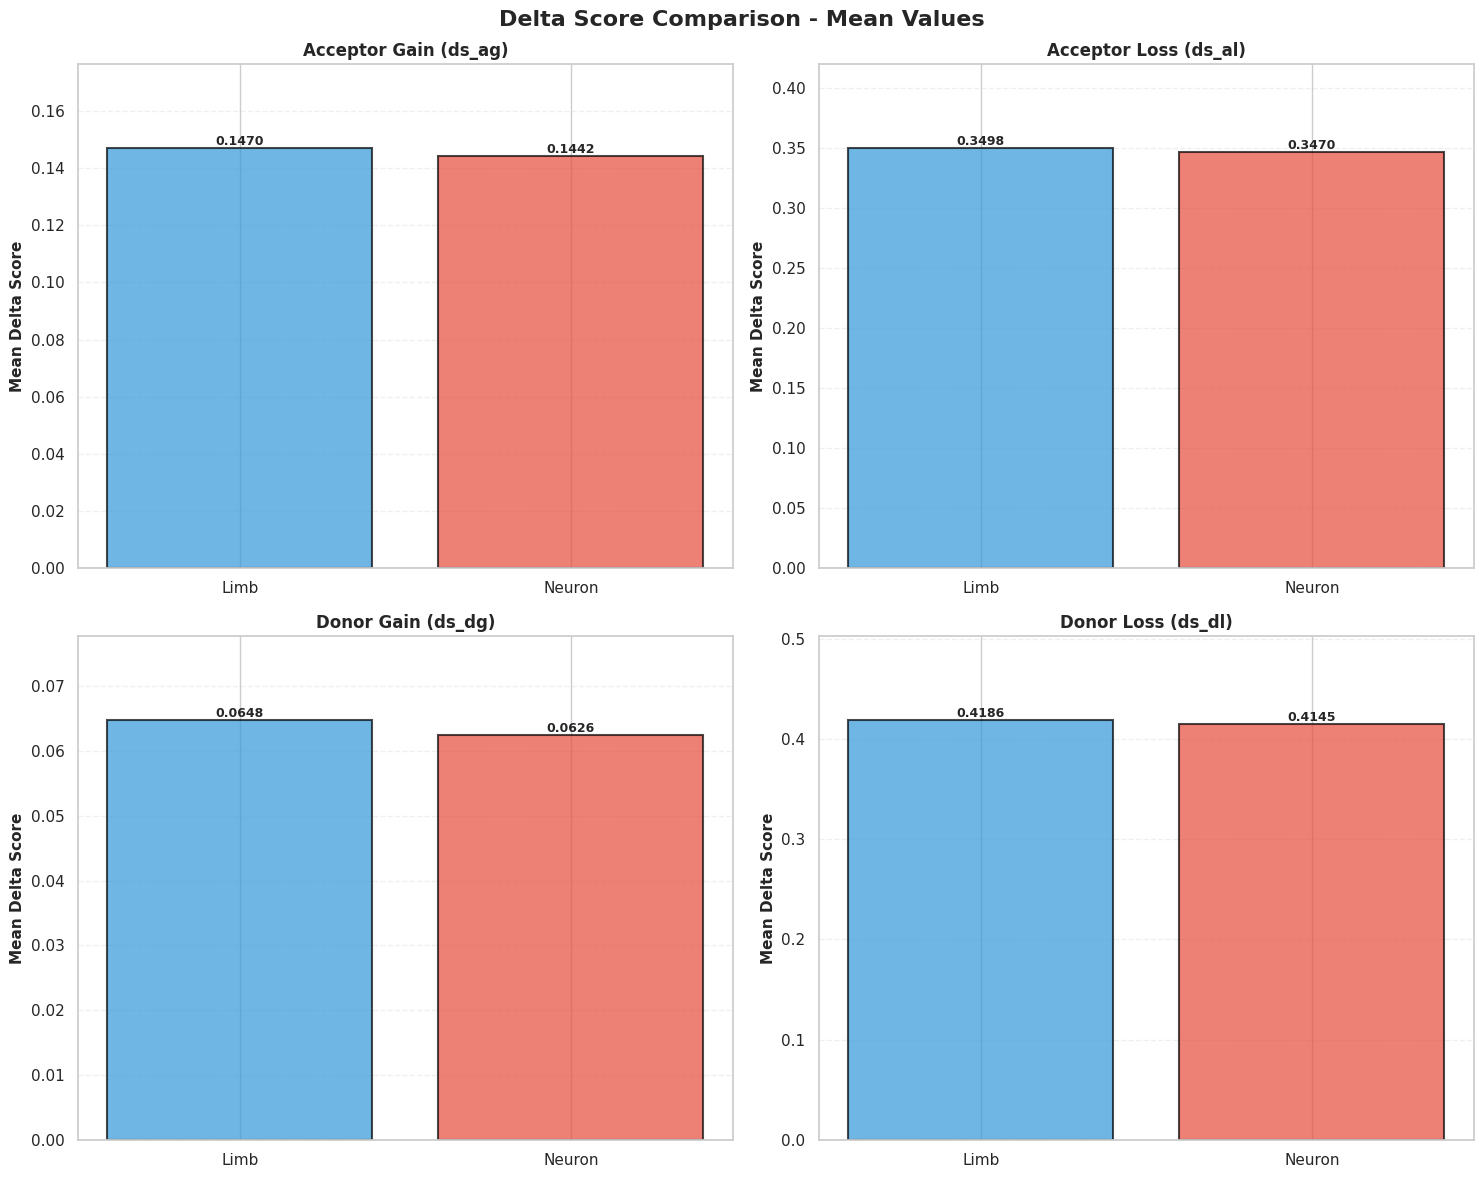


所有剪接类型的均值统计

Acceptor Gain (ds_ag):
  Limb:   0.147037
  Neuron: 0.144156

Acceptor Loss (ds_al):
  Limb:   0.349794
  Neuron: 0.346955

Donor Gain (ds_dg):
  Limb:   0.064774
  Neuron: 0.062551

Donor Loss (ds_dl):
  Limb:   0.418601
  Neuron: 0.414527


In [50]:
import matplotlib.pyplot as plt
import numpy as np

# 创建2x2子图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Delta Score Comparison - Mean Values', fontsize=16, fontweight='bold')

score_types = ['ag', 'al', 'dg', 'dl']
score_names = ['Acceptor Gain', 'Acceptor Loss', 'Donor Gain', 'Donor Loss']
colors = ['#3498db', '#e74c3c']

for idx, (score_type, score_name) in enumerate(zip(score_types, score_names)):
    ax = axes[idx // 2, idx % 2]
    
    # 计算limb和neuron的均值
    limb_col = f'ds_{score_type}_limb'
    neuron_col = f'ds_{score_type}_neuron'
    
    means = [
        merged_df_sp[limb_col].mean(),
        merged_df_sp[neuron_col].mean()
    ]
    
    # 画柱状图
    bars = ax.bar(['Limb', 'Neuron'], means, color=colors, alpha=0.7, 
                   edgecolor='black', linewidth=1.5)
    
    # 在柱子上显示数值
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 美化
    ax.set_ylabel('Mean Delta Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{score_name} (ds_{score_type})', fontsize=12, fontweight='bold')
    ax.set_ylim(min(means) * 1.2 if min(means) < 0 else 0, max(means) * 1.2)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('delta_score_mean_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印统计表
print("\n" + "="*70)
print("所有剪接类型的均值统计")
print("="*70)
for score_type, score_name in zip(score_types, score_names):
    print(f"\n{score_name} (ds_{score_type}):")
    print(f"  Limb:   {merged_df_sp[f'ds_{score_type}_limb'].mean():.6f}")
    print(f"  Neuron: {merged_df_sp[f'ds_{score_type}_neuron'].mean():.6f}")

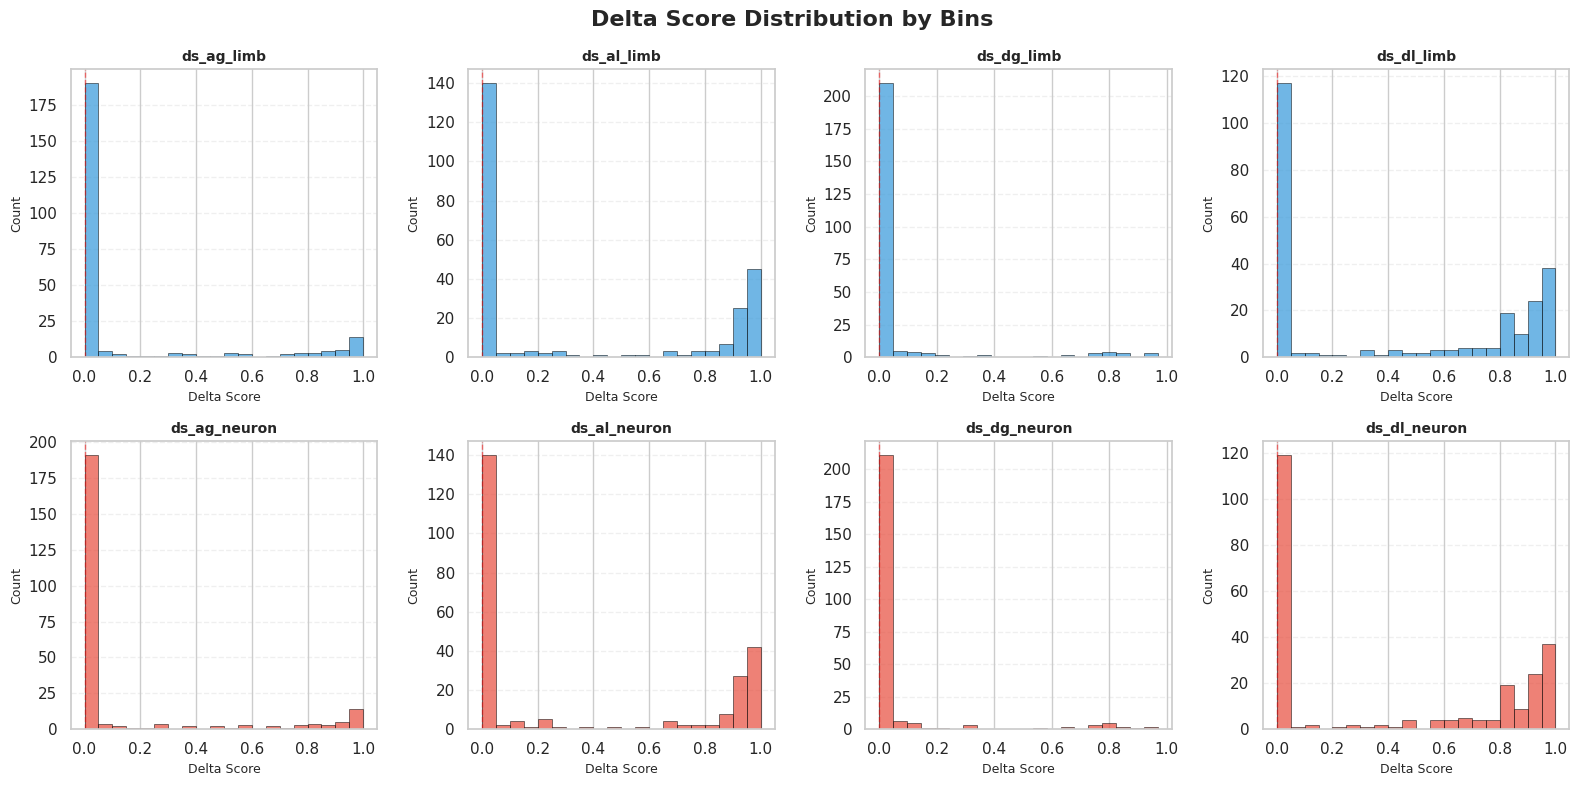


区间分布统计 (以ds_ag_limb为例):
-1.0 ~ -0.5: 0 个
-0.5 ~ 0.0: 0 个
0.0 ~ 0.5: 206 个
0.5 ~ 0.8: 11 个
0.8 ~ 0.9: 7 个
0.9 ~ 1.0: 19 个


In [51]:
import matplotlib.pyplot as plt

# 创建2x4子图
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Delta Score Distribution by Bins', fontsize=16, fontweight='bold')

columns = ['ds_ag_limb', 'ds_al_limb', 'ds_dg_limb', 'ds_dl_limb',
           'ds_ag_neuron', 'ds_al_neuron', 'ds_dg_neuron', 'ds_dl_neuron']

colors = ['#3498db']*4 + ['#e74c3c']*4

for idx, col in enumerate(columns):
    ax = axes[idx // 4, idx % 4]
    
    # 画直方图，设置bins
    data = merged_df_sp[col].dropna()
    n, bins, patches = ax.hist(data, bins=20, color=colors[idx], 
                                alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # 美化
    ax.set_xlabel('Delta Score', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('delta_score_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印区间统计
print("\n区间分布统计 (以ds_ag_limb为例):")
print("="*50)
data = merged_df_sp['ds_ag_limb'].dropna()
bins = [-1, -0.5, 0, 0.5, 0.8, 0.9, 1.0]
counts, _ = np.histogram(data, bins=bins)
for i in range(len(bins)-1):
    print(f"{bins[i]:.1f} ~ {bins[i+1]:.1f}: {counts[i]} 个")